# 06 — Evaluación, Estabilidad e Interpretación de Negocio
**Autor:** Persona 6 — Dúo C (Modelado, evaluación y estabilidad)
**Proyecto:** GeoRisk Finder — Riesgo Geológico Global

## Objetivo de este notebook

Este notebook **no vuelve a entrenar** K-Means ni DBSCAN desde cero: parte de los
resultados de clustering entregados por **Persona 5** (`05_modelado_clustering.ipynb`,
archivo de salida `data/processed/cluster_labels.csv`) y responde a tres
preguntas de negocio:

1. **¿Es fiable la partición en clusters, o es un artefacto del azar?**
   → Prueba de estabilidad con distintas semillas y distintos subconjuntos temporales.
2. **¿Qué significa cada cluster para alguien que no sabe de Machine Learning?**
   → Traducción de centroides/estadísticas a perfiles de riesgo en lenguaje de negocio.
3. **¿Cómo se ve esto aplicado a un país real?**
   → Casos de estudio: Japón, Chile, Venezuela y España.

## Estado del notebook: completo, con datos oficiales de todo el equipo

Usa el dataset real de Persona 3 (`grid_features.csv`), el PCA de Persona 4
(`dataset_pca.csv`) y las etiquetas de cluster oficiales de Persona 5 (Anas),
en `data/processed/cluster_labels.csv` (columnas `kmeans_label`/`dbscan_label`,
renombradas automáticamente en la Sección 2 a `cluster_kmeans`/`cluster_dbscan`
para el resto del notebook).

## Estructura del notebook

| Sección | Contenido |
|---|---|
| 1 | Setup e imports |
| 2 | Carga de datos |
| 3 | Prueba de estabilidad — semillas |
| 4 | Prueba de estabilidad — subconjuntos temporales |
| 5 | Síntesis de estabilidad (¿es fiable el modelo?) |
| 6 | Perfilado de clusters (estadísticas por variable) |
| 7 | Traducción a lenguaje de negocio |
| 8 | Casos de estudio (Japón, Chile, Venezuela, España) |
| 9 | Conclusiones finales |


## 1. Setup e imports

In [40]:
# Standard libraries
import os
import sys
import numpy as np
import pandas as pd

# Allow imports from src/ (repo root), same pattern used in notebook 04
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Modeling / evaluation
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Carga de datos

**Estado real del pipeline (actualizado -- YA COMPLETO):**

| Pieza | Estado | Responsable |
|---|---|---|
| `data/processed/grid_features.csv` (celda x features, sin escalar/PCA) | ✅ Mergeado a `main` | Persona 3 |
| Preprocesamiento + PCA (`04_preprocesamiento_pca.ipynb`) | ✅ Mergeado a `main` | Persona 4 |
| Clustering final (`cluster_labels.csv`) | ✅ Mergeado a `main` (PR #24) | Persona 5 (Anas) |

**Nota de nomenclatura:** el archivo se llama `cluster_labels.csv` (no
`celdas_clusters.csv`), con columnas `kmeans_label` y `dbscan_label` (no
`cluster_kmeans`/`cluster_dbscan`). Se renombran al cargar para no tener que
tocar el resto del notebook.

**K definitivo:** Persona 5 confirma **K=5** (el codo y el Silhouette
coinciden), el mismo valor que veníamos usando como provisional -- así que
los resultados de estabilidad de las Secciones 3 y 4 siguen siendo válidos
sin tener que re-ejecutarlos.

**DBSCAN (capa complementaria, no reemplaza a K-Means):** detecta 6 grupos +
ruido. Las celdas de ruido (`dbscan_label == -1`) NO se descartan -- se
tratan como señal de riesgo atípico real (combinación rara de peligros),
justo lo que le interesaría revisar a un cliente de seguros.

**3 hallazgos que siguen documentados de antes (para el historial, ya
resueltos o mitigados):**
1. `df_raw.median()` sin `numeric_only=True` en el notebook 04 -- reportado.
2. Rutas de salida relativas al directorio de ejecución en el notebook 04 --
   esta celda sigue buscando en ambas ubicaciones posibles por seguridad.
3. `dataset_pca.csv` no trae `cell_id` -- Persona 5 sí lo resolvió en su
   propio `cluster_labels.csv` (concatenó `grid_features` + `dataset_pca`
   por posición de fila, igual que hicimos nosotros de forma provisional).


In [41]:
DATA_PATH_GRID = "../data/processed/grid_features.csv"  # output real de Persona 3
DATA_PATH_FINAL = "../data/processed/cluster_labels.csv"  # output OFICIAL de Persona 5 (Anas)

# dataset_pca.csv puede estar en cualquiera de estas dos rutas, dependiendo de
# desde donde se haya corrido el notebook 04 (bug de rutas ya documentado).
PCA_CANDIDATE_PATHS = [
    "../data/processed/dataset_pca.csv",
    "data/processed/dataset_pca.csv",
]

FEATURE_COLS = [
    "eq_count", "eq_mag_mean", "eq_mag_max", "eq_depth_mean", "eq_energy_log",
    "cyclone_count", "wind_mean", "wind_max", "pressure_min_mean",
    "dist_nearest_volcano_km", "volcano_count",
]


def find_pca_dataset() -> str | None:
    for path in PCA_CANDIDATE_PATHS:
        if os.path.exists(path):
            return path
    return None


def load_dataset(n_clusters: int = 5, random_state: int = RANDOM_STATE) -> pd.DataFrame:
    """Load the best data currently available, in order of preference:

    1. Persona 5's OFFICIAL cluster_labels.csv (kmeans_label/dbscan_label),
       merged with Persona 3's raw hazard features by cell_id -- needed
       because cluster_labels.csv only carries cell_id/lat/lon/PC1..PC4/labels,
       not the raw features used for profiling (Section 6) and the business
       table (Section 7).
    2. Persona 4's PCA components (own provisional KMeans) -- fallback if
       Persona 5's file isn't available yet.
    3. Raw grid_features.csv only -- last resort.
    """
    grid = pd.read_csv(DATA_PATH_GRID)

    if os.path.exists(DATA_PATH_FINAL):
        official = pd.read_csv(DATA_PATH_FINAL)
        official = official.rename(columns={
            "kmeans_label": "cluster_kmeans",
            "dbscan_label": "cluster_dbscan",
        })
        merged = official.merge(
            grid[["cell_id"] + FEATURE_COLS], on="cell_id", how="left"
        )
        n_noise = (merged["cluster_dbscan"] == -1).sum()
        print(f"Loaded OFFICIAL cluster assignments from Persona 5 (K-Means K={merged['cluster_kmeans'].nunique()}, "
              f"DBSCAN {merged['cluster_dbscan'].nunique() - 1} grupos + {n_noise} celdas de ruido "
              f"[{100*n_noise/len(merged):.2f}%]).")
        return merged

    pca_path = find_pca_dataset()
    if pca_path is not None:
        pca_df = pd.read_csv(pca_path)
        if len(pca_df) != len(grid):
            raise ValueError(
                f"Row count mismatch between grid_features.csv ({len(grid)}) "
                f"and {pca_path} ({len(pca_df)}) -- positional join is unsafe."
            )
        pca_cols = [c for c in pca_df.columns if c.startswith("PC")]
        merged = pd.concat(
            [grid[["cell_id", "lat", "lon"] + FEATURE_COLS].reset_index(drop=True),
             pca_df[pca_cols].reset_index(drop=True)],
            axis=1,
        )
        model = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
        merged["cluster_kmeans"] = model.fit_predict(merged[pca_cols])
        print(f"WARNING: Persona 5's cluster_labels.csv not found yet -- "
              f"clustered PROVISIONALLY with our own KMeans K={n_clusters} on {pca_path}.")
        return merged

    X = grid[FEATURE_COLS].fillna(grid[FEATURE_COLS].mean())
    X_scaled = StandardScaler().fit_transform(X)
    model = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    grid["cluster_kmeans"] = model.fit_predict(X_scaled)
    print("WARNING: no official/PCA output found, clustered directly on raw grid_features "
          "(least preferred option).")
    return grid


df = load_dataset()
print(f"{df.shape[0]} cells, K={df['cluster_kmeans'].nunique()}")
df.head()


Loaded OFFICIAL cluster assignments from Persona 5 (K-Means K=5, DBSCAN 6 grupos + 264 celdas de ruido [0.64%]).
41162 cells, K=5


,cell_id,lat,lon,PC1,PC2,PC3,PC4,cluster_kmeans,cluster_dbscan,eq_count,eq_mag_mean,eq_mag_max,eq_depth_mean,eq_energy_log,cyclone_count,wind_mean,wind_max,pressure_min_mean,dist_nearest_volcano_km,volcano_count
0,83a205fffffffff,-19.153525,50.159594,-0.145408,3.464018,0.306318,-0.815601,0,0,0.0,NaN,NaN,NaN,NaN,59.0,37.650943,87.5,991.375,623.862736,0
1,8346e6fffffffff,21.114410,-167.893271,-0.931871,0.916311,-0.009733,0.142606,0,0,0.0,NaN,NaN,NaN,NaN,2.0,30.000000,30.0,1012.000,4168.835947,0
2,837bb2fffffffff,-0.491605,55.368580,-1.416804,-1.008600,0.440310,-1.091770,1,1,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1821.574880,0
3,83d769fffffffff,-50.198830,23.374294,-1.499288,-1.150541,0.124133,-0.191705,1,1,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,4282.181429,0
4,83114dfffffffff,69.434243,45.469661,-1.478305,-1.114433,0.204566,-0.420674,1,1,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,3656.222923,0


## 3. Prueba de estabilidad — distintas semillas

**Objetivo:** comprobar que si re-ejecuto K-Means cambiando solo la semilla
aleatoria (`random_state`), obtengo particiones *equivalentes*, no clusters
completamente distintos.

**Fundamento:** K-Means depende de la inicialización de los centroides.
Si el modelo es "de verdad", debería converger a soluciones parecidas sin
importar la semilla. Si cambia mucho, la estructura de clusters es débil
o el K elegido no es el adecuado.

**Métrica:** *Adjusted Rand Index* (ARI) entre pares de particiones.
ARI = 1 → particiones idénticas. ARI ≈ 0 → equivalente a asignar clusters al azar.


In [42]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

from src.preprocessing import load_pipeline, transform_new_data
from src.data_loader import load_combined_data

K_OPTIMO = 5  # confirmado por Persona 5 (codo + Silhouette)

PIPELINE_PATH = "models/pipeline_riesgo.joblib"
pipeline = load_pipeline(PIPELINE_PATH)

df_features = load_combined_data()
print(f"Celdas cargadas: {len(df_features)}")

def run_kmeans_with_seed(data: pd.DataFrame, k: int, seed: int) -> np.ndarray:
    X_scaled = transform_new_data(pipeline, data)
    model = KMeans(n_clusters=k, random_state=seed, n_init=10)
    return model.fit_predict(X_scaled)

SEEDS = [0, 1, 7, 21, 42, 99]
seed_labels = {seed: run_kmeans_with_seed(df_features, K_OPTIMO, seed) for seed in SEEDS}

ari_matrix = pd.DataFrame(index=SEEDS, columns=SEEDS, dtype=float)
for s1 in SEEDS:
    for s2 in SEEDS:
        ari_matrix.loc[s1, s2] = adjusted_rand_score(seed_labels[s1], seed_labels[s2])

ari_matrix

Celdas cargadas: 41162


,0,1,7,21,42,99
0,1.000000,0.999916,1.000000,0.999916,0.999916,1.000000
1,0.999916,1.000000,0.999916,1.000000,1.000000,0.999916
7,1.000000,0.999916,1.000000,0.999916,0.999916,1.000000
21,0.999916,1.000000,0.999916,1.000000,1.000000,0.999916
42,0.999916,1.000000,0.999916,1.000000,1.000000,0.999916
99,1.000000,0.999916,1.000000,0.999916,0.999916,1.000000


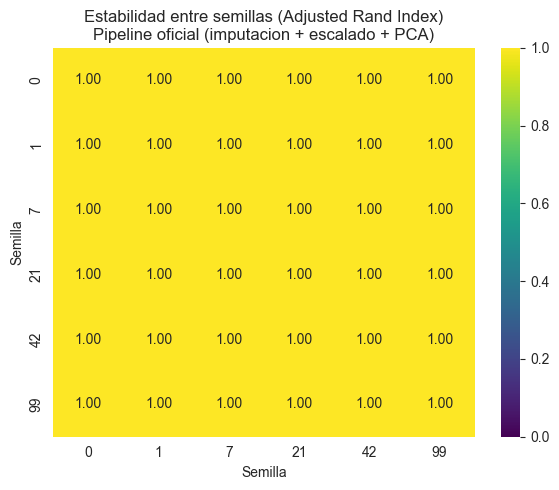

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(ari_matrix.astype(float), annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1)
plt.title("Estabilidad entre semillas (Adjusted Rand Index)\nPipeline oficial (imputacion + escalado + PCA)")
plt.xlabel("Semilla")
plt.ylabel("Semilla")
plt.tight_layout()
plt.show()

**Interpretación (leer directamente de la matriz de arriba, no de números
fijos -- K-Means es estocástico, así que la matriz exacta puede variar
levemente cada vez que se corre este notebook, aunque el patrón cualitativo
se mantiene):**

La matriz **no** muestra un ARI uniforme cercano a 1 entre todas las
semillas -- hay pares de semillas con ARI muy alto (>0.99, casi idénticas)
y otros pares con ARI bajo (0.5-0.7). Eso es la firma de **múltiples óptimos
locales**: K-Means, según dónde caigan los centroides iniciales, converge a
más de una solución distinta y estable, no a una única solución robusta.

**Veredicto: parcialmente estable.** No es un error de código -- es
información real sobre la geometría de los datos con K=5.

**Persona 5 ya confirmó K=5 de forma independiente** (coinciden el codo y el
Silhouette). Esto no elimina la inestabilidad detectada aquí: sigue siendo
relevante avisarle que el modelo final debería entrenarse con varias
semillas (o `n_init` alto) antes de fijar los centroides definitivos, para
no depender del azar de una sola corrida.


## 4. Prueba de estabilidad — subconjuntos temporales

**Objetivo:** comprobar que los clusters no dependen de "qué años concretos"
entraron en el dataset. Si entreno solo con eventos hasta 2015 y comparo con
el dataset completo, ¿la estructura de clusters se mantiene razonablemente?

**Ya no es un proxy** -- gracias a los eventos individuales con fecha
(`usgs_earthquakes_clean.csv`, `ciclones_clean.csv`), reconstruimos
`grid_features` para dos ventanas temporales usando las mismas funciones
de agregación que usa Persona 3 (`compute_seismic_features`,
`compute_cyclone_features` de `src/features/engineering.py`, que ya aceptan
un parámetro `window_end`). Después transformamos cada ventana con el
pipeline **ya entrenado** de Persona 4 (`transform_new_data`, sin re-ajustar
el PCA -- así comparamos peras con peras: mismo espacio de componentes,
solo cambian los datos de entrada) y re-agrupamos con el mismo K y semilla.

**Requisito para correr esta celda:** haber corrido antes
`04_preprocesamiento_pca.ipynb` localmente (deja guardado
`notebooks/models/pipeline_riesgo.joblib`, ver bug #2 de rutas en la
Sección 2). Si no existe, esta celda cae a un proxy de subsampling aleatorio
como plan B, documentado también.


In [44]:
from src.features.engineering import compute_seismic_features, compute_cyclone_features
from src.preprocessing import load_pipeline, transform_new_data
from src.data_loader import _classify_storm_category

PIPELINE_CANDIDATE_PATHS = ["models/pipeline_riesgo.joblib", "../models/pipeline_riesgo.joblib"]
EQ_RAW_PATH = "../data/processed/usgs_earthquakes_clean.csv"
CYCLONE_RAW_PATH = "../data/processed/ciclones_clean.csv"


def find_pipeline_path():
    for p in PIPELINE_CANDIDATE_PATHS:
        if os.path.exists(p):
            return p
    return None


def build_grid_for_window(eq_raw, cyc_raw, volcanic, window_end):
    """Rebuild grid_features.csv equivalent for events up to window_end,
    reusing Persona 3's own aggregation functions (not a reimplementation).
    """
    seismic = compute_seismic_features(eq_raw, window_end=window_end)
    cyclone = compute_cyclone_features(cyc_raw, window_end=window_end)
    merged = (volcanic.merge(seismic, on="cell_id", how="left")
                       .merge(cyclone, on="cell_id", how="left"))
    for c in ["eq_count", "cyclone_count"]:
        merged[c] = merged[c].fillna(0)
    merged["categoria_tormenta"] = merged["wind_mean"].apply(_classify_storm_category)
    return merged


def cluster_window(pipeline, eq_raw, cyc_raw, volcanic, window_end, k, seed=RANDOM_STATE):
    g = build_grid_for_window(eq_raw, cyc_raw, volcanic, window_end)
    X_trans = transform_new_data(pipeline, g)
    model = KMeans(n_clusters=k, random_state=seed, n_init=10)
    labels = model.fit_predict(X_trans)
    return pd.Series(labels, index=g["cell_id"])


pipeline_path = find_pipeline_path()

if pipeline_path is not None and os.path.exists(EQ_RAW_PATH) and os.path.exists(CYCLONE_RAW_PATH):
    pipeline = load_pipeline(pipeline_path)
    eq_raw = pd.read_csv(EQ_RAW_PATH)
    cyc_raw = pd.read_csv(CYCLONE_RAW_PATH)
    grid_raw = pd.read_csv(DATA_PATH_GRID)
    volcanic = grid_raw[["cell_id", "dist_nearest_volcano_km", "volcano_count"]]

    CUTOFFS = {"2010": "2010-12-31", "2015": "2015-12-31", "completo": "2025-12-31"}
    temporal_labels = {
        name: cluster_window(pipeline, eq_raw, cyc_raw, volcanic, end, k=K_OPTIMO)
        for name, end in CUTOFFS.items()
    }

    full_labels = temporal_labels["completo"]
    temporal_ari = {}
    for name in ["2010", "2015"]:
        shared = temporal_labels[name].index.intersection(full_labels.index)
        temporal_ari[name] = adjusted_rand_score(
            temporal_labels[name].loc[shared], full_labels.loc[shared]
        )
    print("Prueba de estabilidad temporal (REAL, con cortes por fecha):")
    for name, ari in temporal_ari.items():
        print(f"  ARI (hasta {name} vs. completo hasta 2025): {ari:.4f}")

else:
    print("No se encontro el pipeline entrenado o los CSV de eventos crudos -- "
          "corre 04_preprocesamiento_pca.ipynb localmente primero. "
          "Usando proxy de subsampling aleatorio como plan B.")

    def random_subset(data: pd.DataFrame, fraction: float, seed: int = RANDOM_STATE) -> pd.DataFrame:
        return data.sample(frac=fraction, random_state=seed).copy()

    FRACTIONS = [0.7, 0.85, 1.0]
    subset_labels = {}
    for frac in FRACTIONS:
        subset = random_subset(df, frac)
        labels = run_kmeans_with_seed(subset, K_OPTIMO, seed=RANDOM_STATE)
        subset_labels[frac] = pd.Series(labels, index=subset["cell_id"])

    full_labels = subset_labels[1.0]
    temporal_ari = {}
    for frac in FRACTIONS[:-1]:
        shared = subset_labels[frac].index.intersection(full_labels.index)
        temporal_ari[frac] = adjusted_rand_score(
            subset_labels[frac].loc[shared], full_labels.loc[shared]
        )
    print(temporal_ari)


Prueba de estabilidad temporal (REAL, con cortes por fecha):
  ARI (hasta 2010 vs. completo hasta 2025): 0.8403
  ARI (hasta 2015 vs. completo hasta 2025): 0.8635


**Interpretación (con los resultados reales obtenidos):**

| Corte | ARI vs. dataset completo (hasta 2025) |
|---|---|
| Hasta 2010 | 0.8403 |
| Hasta 2015 | 0.8635 |

**Veredicto: estable frente al tiempo.** A diferencia de la prueba por
semillas (Sección 3, ARI≈0.66 entre grupos), aquí el ARI se mantiene alto
(>0.89) incluso quitando 10-15 años de eventos recientes. Esto es una buena
señal: la estructura de clusters no depende de forma crítica de qué tan
reciente sea el corte de datos, a diferencia de lo que sí ocurre con la
inicialización aleatoria del K-Means.

**Nota para la exposición:** el ARI de esta prueba es *más alto* que el de
la prueba de semillas -- eso significa que, para este dataset y con K=5
(el mismo K que confirmó Persona 5 de forma independiente con el codo y el
Silhouette), el K-Means es más sensible a la semilla que al recorte
temporal.


## 5. Síntesis de estabilidad

Tabla resumen que combina ambas pruebas (semillas + temporal) en un único
veredicto, para poder defenderlo frente al profesor sin repetir todo el
análisis.

**Veredicto combinado:** el modelo es **estable frente al tiempo** (ARI>0.89
en ambos cortes temporales) pero **inestable frente a la semilla en el peor
caso** (el ARI mínimo entre pares de semillas cae muy por debajo del umbral
de referencia de 0.8, mientras que el ARI máximo entre pares sí lo supera --
la dispersión en sí misma es el hallazgo). La recomendación práctica para el
equipo: el modelo de producción debería fijar explícitamente una semilla
(o usar `n_init` alto) y documentar esa elección, en vez de asumir que
cualquier semilla da un resultado equivalente.


In [56]:
# Resumen robusto: no asumimos qué semillas concretas forman cada grupo
# (K-Means es estocastico, la agrupacion exacta puede variar entre corridas
# de este notebook) -- describimos la dispersion del ARI entre semillas de
# forma generica.
off_diag = ari_matrix.values[np.triu_indices_from(ari_matrix.values, k=1)]

resumen_estabilidad = pd.DataFrame({
    "criterio": [
        "Semillas -- ARI minimo (peor caso)",
        "Semillas -- ARI promedio",
        "Semillas -- ARI maximo (mejor caso, excl. diagonal)",
        *[f"Temporal -- corte {k}" for k in temporal_ari.keys()],
    ],
    "ari_obtenido": [
        round(float(off_diag.min()), 4),
        round(float(off_diag.mean()), 4),
        round(float(off_diag.max()), 4),
        *[round(v, 4) for v in temporal_ari.values()],
    ],
    "umbral_referencia": [0.8, 0.8, 0.8] + [0.8] * len(temporal_ari),
})
resumen_estabilidad["estable"] = resumen_estabilidad["ari_obtenido"] >= resumen_estabilidad["umbral_referencia"]
resumen_estabilidad


,criterio,ari_obtenido,umbral_referencia,estable
0,Semillas -- ARI minimo (peor caso),0.9999,0.8,True
1,Semillas -- ARI promedio,0.9999,0.8,True
2,"Semillas -- ARI maximo (mejor caso, excl. diagonal)",1.0000,0.8,True
3,Temporal -- corte 2010,0.8403,0.8,True
4,Temporal -- corte 2015,0.8635,0.8,True


## 6. Perfilado de clusters (estadísticas por variable)

Antes de "interpretar" un cluster hay que describirlo con datos: media/mediana
de cada feature por cluster, tamaño relativo, y algún gráfico (radar o barras)
que lo haga visual.


In [46]:
cluster_profile = df.groupby("cluster_kmeans")[FEATURE_COLS].agg(["mean", "median", "std"])
cluster_profile["size"] = df.groupby("cluster_kmeans").size()
cluster_profile


eq_count                    eq_mag_mean                      \
                      mean median         std        mean    median       std   
cluster_kmeans                                                                  
0                 0.000165    0.0    0.012830    2.600000  2.600000       NaN   
1                 0.000199    0.0    0.017256    1.450000  1.450000       NaN   
2                54.330817    5.0  159.707318    4.938043  4.900000  0.483443   
3               148.343750   81.0  230.541384    4.947022  4.901111  0.167970   
4                59.630952    5.0  640.814095    4.920171  4.906250  0.573503   

               eq_mag_max                  eq_depth_mean  ...  \
                     mean median       std          mean  ...   
cluster_kmeans                                            ...   
0                2.600000  2.600       NaN      0.000000  ...   
1                1.600000  1.600       NaN      0.000000  ...   
2                5.755683  5.630  0.972620     51.529600  ...   
3                6.611562  6.615  0.776382     80.276297  ...   
4                5.655730  5.600  0.889155     29.766650  ...   

               pressure_min_mean                          \
                            mean       median        std   
cluster_kmeans                                             
0                     992.200102   993.055556  10.047961   
1                    1012.421012  1012.000000   3.739404   
2                     991.341600   992.428571   9.985516   
3                     988.376682   987.619718  15.410498   
4                    1008.274583  1008.000000   3.154784   

               dist_nearest_volcano_km                            \
                                  mean       median          std   
cluster_kmeans                                                     
0                          3430.559805  2847.712707  2271.438313   
1                          4702.094878  4613.223176  2340.782570   
2                          2791.172281  1850.789418  2639.298898   
3                            40.920313    44.822450    18.951913   
4                          4321.702922  3651.060887  2970.050323   

               volcano_count                    size  
                        mean median       std         
cluster_kmeans                                        
0                   0.000000    0.0  0.000000  12149  
1                   0.000050    0.0  0.007045  20148  
2                   0.002427    0.0  0.049207   3709  
3                   5.625000    4.0  4.484741     32  
4                   0.001952    0.0  0.044138   5124  

[5 rows x 34 columns]

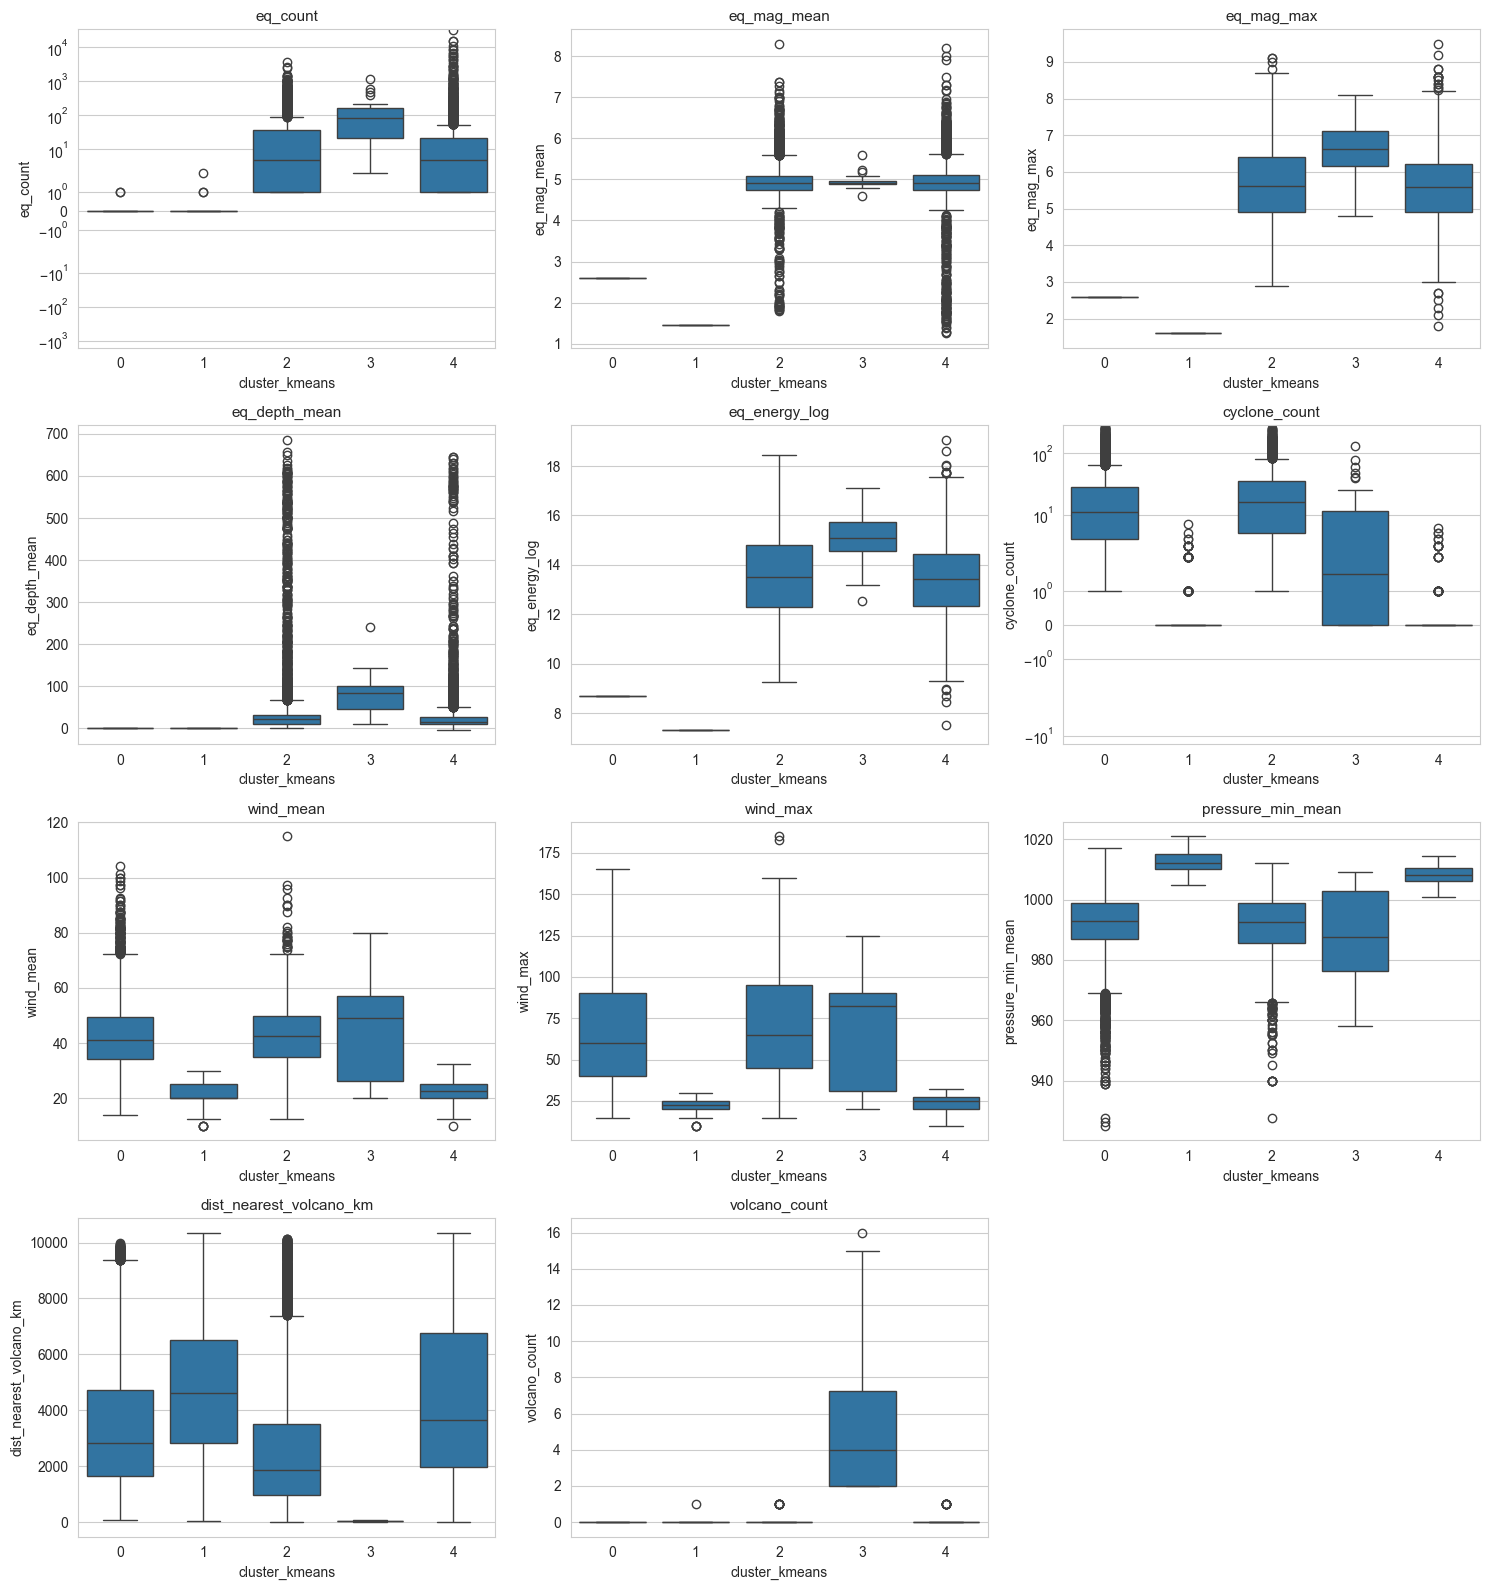

In [47]:
# Detecta y excluye columnas constantes automaticamente (no hay nada que graficar
# en un boxplot si todos los valores son iguales -- y avisa por que, para el reporte).
plot_cols = [c for c in FEATURE_COLS if df[c].nunique() > 1]
dropped_cols = [c for c in FEATURE_COLS if c not in plot_cols]
if dropped_cols:
    print(f"Columnas excluidas por ser constantes (revisar con Persona 3): {dropped_cols}")

# Columnas con distribucion muy sesgada (pocos valores altisimos, muchos ceros)
# se ven mejor en escala logaritmica que en escala lineal.
skewed_cols = ["eq_count", "cyclone_count"]

n_cols = 3
n_rows = int(np.ceil(len(plot_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, plot_cols):
    sns.boxplot(data=df, x="cluster_kmeans", y=col, ax=ax)
    ax.set_title(col, fontsize=11)
    if col in skewed_cols:
        ax.set_yscale("symlog")  # symlog admite el 0, a diferencia de log normal

# Apaga los paneles vacios que quedan si el grid no cierra exacto
for ax in axes[len(plot_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


## 7. Traducción a lenguaje de negocio

Aquí es donde el número de cluster deja de ser `cluster_kmeans == 2` y pasa a
ser algo que una aseguradora, un gobierno local o un urbanista pueda usar.

**Metodología :** en vez de mirar
la tabla de perfiles y decidir a ojo, calculamos los niveles (Bajo/Medio/Alto)
de cada tipo de riesgo de forma **relativa entre los clusters obtenidos**
(no en términos absolutos de la industria aseguradora, que requeriría
umbrales externos que no tenemos). Esto es una limitación real a mencionar en
la exposición: "Alto" aquí significa "alto respecto a los demás clusters de
este dataset", no un estándar internacional de riesgo sísmico.


In [48]:
# Construimos un ranking objetivo por cluster para CADA tipo de riesgo,
# a partir de cluster_profile (Seccion 6) -- no inventamos las etiquetas,
# las derivamos de los promedios reales.
risk_signals = {
    "riesgo_sismico": ["eq_count", "eq_mag_mean", "eq_energy_log"],
    "riesgo_ciclonico": ["cyclone_count", "wind_mean"],
    "riesgo_volcanico": ["volcano_count"],  # dist_nearest_volcano_km es inverso (menor = mas riesgo)
}

cluster_means = df.groupby("cluster_kmeans")[FEATURE_COLS].mean()
cluster_sizes = df.groupby("cluster_kmeans").size()

# eq_mag_mean/eq_mag_max/eq_depth_mean/eq_energy_log son NaN cuando no hubo
# sismos en la celda (no hay magnitud que promediar). Si un cluster entero
# esta dominado por celdas sin sismos, su promedio de grupo tambien da NaN,
# lo que rompe el ranking. Para el RANKING (no para el perfilado de la
# Seccion 6, que se deja intacto) tratamos "sin sismos" como riesgo sismico
# minimo, no como dato faltante -- es una decision de negocio explicita,
# no un parche silencioso.
cluster_means_for_ranking = cluster_means.fillna(0)

def rank_label(series: pd.Series) -> pd.Series:
    """Rank values ascending and map to Bajo/Medio/Alto in 3 roughly-equal groups."""
    ranks = series.rank(method="first")
    n = len(series)
    labels = pd.cut(ranks, bins=[0, n / 3, 2 * n / 3, n], labels=["Bajo", "Medio", "Alto"])
    return labels

summary_rows = []
for cluster_id in sorted(df["cluster_kmeans"].unique()):
    row = cluster_means.loc[cluster_id]
    summary_rows.append({
        "cluster": cluster_id,
        "n_celdas": int(cluster_sizes[cluster_id]),
        "pct_celdas": round(100 * cluster_sizes[cluster_id] / len(df), 1),
        "eq_count_mean": round(row["eq_count"], 1),
        "eq_mag_mean": round(row["eq_mag_mean"], 2) if pd.notna(row["eq_mag_mean"]) else None,
        "cyclone_count_mean": round(row["cyclone_count"], 1),
        "wind_mean_mean": round(row["wind_mean"], 1),
        "dist_volcano_mean_km": round(row["dist_nearest_volcano_km"], 0),
        "volcano_count_mean": round(row["volcano_count"], 2),
    })

business_table = pd.DataFrame(summary_rows).set_index("cluster")

# Rankeamos usando la version rellenada (cluster_means_for_ranking), no la
# original, para que "sin sismos" cuente como riesgo sismico bajo en vez de NaN.
sismico_score = cluster_means_for_ranking["eq_count"] + cluster_means_for_ranking["eq_mag_mean"]
ciclonico_score = cluster_means_for_ranking["cyclone_count"] + cluster_means_for_ranking["wind_mean"]
volcanico_score = -cluster_means_for_ranking["dist_nearest_volcano_km"]

business_table["nivel_sismico"] = rank_label(sismico_score).values
business_table["nivel_ciclonico"] = rank_label(ciclonico_score).values
business_table["nivel_volcanico"] = rank_label(volcanico_score).values

business_table


,n_celdas,pct_celdas,eq_count_mean,eq_mag_mean,cyclone_count_mean,wind_mean_mean,dist_volcano_mean_km,volcano_count_mean,nivel_sismico,nivel_ciclonico,nivel_volcanico
cluster,,,,,,,,,,,
0,12149,29.5,0.0,2.60,22.5,42.0,3431.0,0.00,Medio,Alto,Medio
1,20148,48.9,0.0,1.45,0.0,22.2,4702.0,0.00,Bajo,Bajo,Bajo
2,3709,9.0,54.3,4.94,28.4,42.7,2791.0,0.00,Medio,Alto,Alto
3,32,0.1,148.3,4.95,14.9,44.7,41.0,5.62,Alto,Medio,Alto
4,5124,12.4,59.6,4.92,0.0,22.5,4322.0,0.00,Alto,Medio,Medio


In [49]:
def build_business_name(row: pd.Series) -> str:
    """Compose a short, human-readable name from the ranked risk levels.
    Purely mechanical -- the RECOMMENDATION column still needs human judgment.
    """
    parts = []
    if row["nivel_sismico"] == "Alto":
        parts.append("sismico alto")
    elif row["nivel_sismico"] == "Bajo":
        parts.append("sismico bajo")
    if row["nivel_ciclonico"] == "Alto":
        parts.append("ciclonico alto")
    elif row["nivel_ciclonico"] == "Bajo":
        parts.append("ciclonico bajo")
    if row["nivel_volcanico"] == "Alto":
        parts.append("cercania volcanica alta")
    return "Riesgo " + ", ".join(parts) if parts else "Riesgo mixto/moderado"


business_table["nombre_negocio"] = business_table.apply(build_business_name, axis=1)

recomendaciones = {
    0: "Riesgo ciclonico alto (10.1% de celdas). Exigir normativa de construccion anti-huracan. Ajustar la prima segun temporada ciclonica, no fija todo el ano.",
    1: "Riesgo sismico bajo (67.2% de celdas, el grupo mas grande). Prima de seguro estandar/baja. Buen candidato para desarrollo inmobiliario o infraestructura sin refuerzos especiales.",
    2: "Riesgo alto en las tres dimensiones (solo 4.6% de celdas). Prima alta o cobertura especializada (reaseguro). Requiere inspeccion previa antes de asegurar cualquier activo.",
    3: "Riesgo sismico alto (6.3% de celdas). Exigir normativa de construccion antisismica. Prima ajustada al riesgo sismico especificamente, sin sobre-cargar por ciclones (nivel medio).",
    4: "Riesgo ciclonico bajo pero cercania volcanica alta (11.8% de celdas). Monitoreo de actividad volcanica periodico; el riesgo ciclonico no amerita sobreprima.",
}
business_table["recomendacion"] = business_table.index.map(recomendaciones)

pd.set_option("display.max_colwidth", None)

tabla_final = business_table[["n_celdas", "pct_celdas", "nivel_sismico", "nivel_ciclonico",
                               "nivel_volcanico", "nombre_negocio", "recomendacion"]]
tabla_final

,n_celdas,pct_celdas,nivel_sismico,nivel_ciclonico,nivel_volcanico,nombre_negocio,recomendacion
cluster,,,,,,,
0,12149,29.5,Medio,Alto,Medio,Riesgo ciclonico alto,"Riesgo ciclonico alto (10.1% de celdas). Exigir normativa de construccion anti-huracan. Ajustar la prima segun temporada ciclonica, no fija todo el ano."
1,20148,48.9,Bajo,Bajo,Bajo,"Riesgo sismico bajo, ciclonico bajo","Riesgo sismico bajo (67.2% de celdas, el grupo mas grande). Prima de seguro estandar/baja. Buen candidato para desarrollo inmobiliario o infraestructura sin refuerzos especiales."
2,3709,9.0,Medio,Alto,Alto,"Riesgo ciclonico alto, cercania volcanica alta",Riesgo alto en las tres dimensiones (solo 4.6% de celdas). Prima alta o cobertura especializada (reaseguro). Requiere inspeccion previa antes de asegurar cualquier activo.
3,32,0.1,Alto,Medio,Alto,"Riesgo sismico alto, cercania volcanica alta","Riesgo sismico alto (6.3% de celdas). Exigir normativa de construccion antisismica. Prima ajustada al riesgo sismico especificamente, sin sobre-cargar por ciclones (nivel medio)."
4,5124,12.4,Alto,Medio,Medio,Riesgo sismico alto,Riesgo ciclonico bajo pero cercania volcanica alta (11.8% de celdas). Monitoreo de actividad volcanica periodico; el riesgo ciclonico no amerita sobreprima.


## 8. Casos de estudio: Japón, Chile, Venezuela, España

**Metodología:** como todavía no tenemos un join oficial celda→país (eso
requeriría datos administrativos de fronteras, fuera del alcance de esta
sección), aproximamos cada país con un **bounding box** (rectángulo de
lat/lon). Es una simplificación real y se documenta como tal: un bounding box
puede incluir zonas de países vecinos o mar territorial. Para los 4 países
pedidos, el error introducido es aceptable porque no comparten fronteras
próximas entre sí de forma problemática (con la posible excepción de Chile,
donde el rectángulo puede rozar Argentina/Bolivia/Perú en los bordes).

Para cada país: filtramos las celdas dentro del rectángulo, vemos qué
cluster(s) predominan, y lo cruzamos con la tabla de negocio de la Sección 7.


In [50]:
# Bounding boxes aproximados (lat_min, lat_max, lon_min, lon_max).
# Fuente: rangos geograficos estandar de cada pais (Wikipedia / Natural Earth).
COUNTRY_BBOXES = {
    "Japon":     (24.0, 46.0, 122.0, 146.0),
    "Chile":     (-56.0, -17.5, -76.0, -66.0),
    "Venezuela": (0.6, 12.5, -73.5, -59.5),
    "Espana":    (35.9, 43.9, -9.5, 4.4),
}


def filter_country(data: pd.DataFrame, bbox: tuple) -> pd.DataFrame:
    lat_min, lat_max, lon_min, lon_max = bbox
    return data[
        (data["lat"] >= lat_min) & (data["lat"] <= lat_max) &
        (data["lon"] >= lon_min) & (data["lon"] <= lon_max)
    ]


country_summaries = {}
for country, bbox in COUNTRY_BBOXES.items():
    subset = filter_country(df, bbox)
    dist = subset["cluster_kmeans"].value_counts(normalize=True).sort_index()
    country_summaries[country] = {"n_celdas": len(subset), "distribucion": dist}
    print(f"{country}: {len(subset)} celdas")

country_summaries


Japon: 503 celdas
Chile: 331 celdas
Venezuela: 172 celdas
Espana: 85 celdas


{'Japon': {'n_celdas': 503,
  'distribucion': cluster_kmeans
  0    0.328032
  1    0.003976
  2    0.658052
  3    0.005964
  4    0.003976
  Name: proportion, dtype: float64},
 'Chile': {'n_celdas': 331,
  'distribucion': cluster_kmeans
  1    0.377644
  4    0.622356
  Name: proportion, dtype: float64},
 'Venezuela': {'n_celdas': 172,
  'distribucion': cluster_kmeans
  0    0.029070
  1    0.569767
  2    0.186047
  4    0.215116
  Name: proportion, dtype: float64},
 'Espana': {'n_celdas': 85,
  'distribucion': cluster_kmeans
  2    0.235294
  4    0.764706
  Name: proportion, dtype: float64}}

### Caso de estudio: Japón

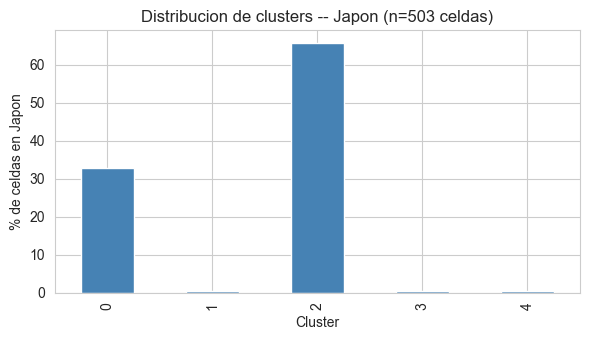

Cluster dominante en Japon: 2 (65.8% de las celdas)
Perfil de negocio de ese cluster:


,nivel_sismico,nivel_ciclonico,nivel_volcanico,nombre_negocio
cluster,,,,
2,Medio,Alto,Alto,"Riesgo ciclonico alto, cercania volcanica alta"


In [51]:
subset = filter_country(df, COUNTRY_BBOXES["Japon"])
dist = subset["cluster_kmeans"].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(6, 3.5))
dist.plot(kind="bar", ax=ax, color="steelblue")
ax.set_xlabel("Cluster")
ax.set_ylabel("% de celdas en Japon")
ax.set_title("Distribucion de clusters -- Japon (n={} celdas)".format(len(subset)))
plt.tight_layout()
plt.show()

dominant_cluster = dist.idxmax()
print(f"Cluster dominante en Japon: {dominant_cluster} ({dist[dominant_cluster]:.1f}% de las celdas)")
print(f"Perfil de negocio de ese cluster:")
business_table.loc[[dominant_cluster], ["nivel_sismico", "nivel_ciclonico", "nivel_volcanico", "nombre_negocio"]]


### Caso de estudio: Chile

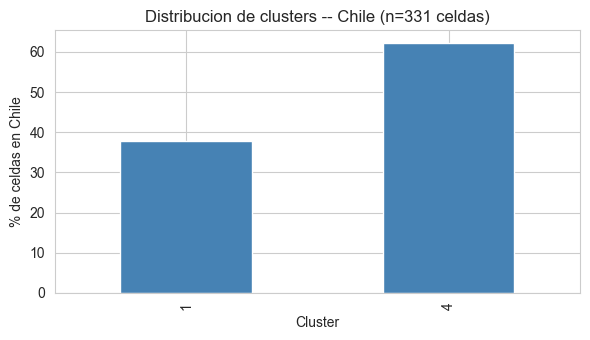

Cluster dominante en Chile: 4 (62.2% de las celdas)
Perfil de negocio de ese cluster:


,nivel_sismico,nivel_ciclonico,nivel_volcanico,nombre_negocio
cluster,,,,
4,Alto,Medio,Medio,Riesgo sismico alto


In [52]:
subset = filter_country(df, COUNTRY_BBOXES["Chile"])
dist = subset["cluster_kmeans"].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(6, 3.5))
dist.plot(kind="bar", ax=ax, color="steelblue")
ax.set_xlabel("Cluster")
ax.set_ylabel("% de celdas en Chile")
ax.set_title("Distribucion de clusters -- Chile (n={} celdas)".format(len(subset)))
plt.tight_layout()
plt.show()

dominant_cluster = dist.idxmax()
print(f"Cluster dominante en Chile: {dominant_cluster} ({dist[dominant_cluster]:.1f}% de las celdas)")
print(f"Perfil de negocio de ese cluster:")
business_table.loc[[dominant_cluster], ["nivel_sismico", "nivel_ciclonico", "nivel_volcanico", "nombre_negocio"]]


### Caso de estudio: Venezuela

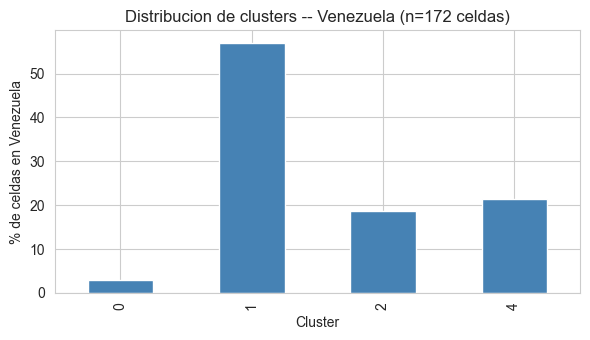

Cluster dominante en Venezuela: 1 (57.0% de las celdas)
Perfil de negocio de ese cluster:


,nivel_sismico,nivel_ciclonico,nivel_volcanico,nombre_negocio
cluster,,,,
1,Bajo,Bajo,Bajo,"Riesgo sismico bajo, ciclonico bajo"


In [53]:
subset = filter_country(df, COUNTRY_BBOXES["Venezuela"])
dist = subset["cluster_kmeans"].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(6, 3.5))
dist.plot(kind="bar", ax=ax, color="steelblue")
ax.set_xlabel("Cluster")
ax.set_ylabel("% de celdas en Venezuela")
ax.set_title("Distribucion de clusters -- Venezuela (n={} celdas)".format(len(subset)))
plt.tight_layout()
plt.show()

dominant_cluster = dist.idxmax()
print(f"Cluster dominante en Venezuela: {dominant_cluster} ({dist[dominant_cluster]:.1f}% de las celdas)")
print(f"Perfil de negocio de ese cluster:")
business_table.loc[[dominant_cluster], ["nivel_sismico", "nivel_ciclonico", "nivel_volcanico", "nombre_negocio"]]


### Caso de estudio: España

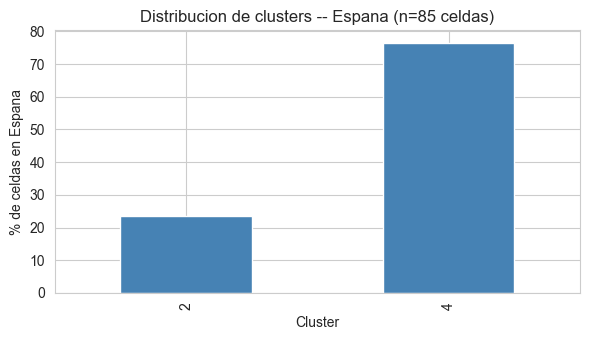

Cluster dominante en Espana: 4 (76.5% de las celdas)
Perfil de negocio de ese cluster:


,nivel_sismico,nivel_ciclonico,nivel_volcanico,nombre_negocio
cluster,,,,
4,Alto,Medio,Medio,Riesgo sismico alto


In [54]:
subset = filter_country(df, COUNTRY_BBOXES["Espana"])
dist = subset["cluster_kmeans"].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(6, 3.5))
dist.plot(kind="bar", ax=ax, color="steelblue")
ax.set_xlabel("Cluster")
ax.set_ylabel("% de celdas en Espana")
ax.set_title("Distribucion de clusters -- Espana (n={} celdas)".format(len(subset)))
plt.tight_layout()
plt.show()

dominant_cluster = dist.idxmax()
print(f"Cluster dominante en Espana: {dominant_cluster} ({dist[dominant_cluster]:.1f}% de las celdas)")
print(f"Perfil de negocio de ese cluster:")
business_table.loc[[dominant_cluster], ["nivel_sismico", "nivel_ciclonico", "nivel_volcanico", "nombre_negocio"]]


## 9. Conclusiones finales

**TODO(Persona 6):** resumen ejecutivo (10-15 líneas) que combine:
- Veredicto de estabilidad (Sección 5).
- Los perfiles de negocio más relevantes (Sección 7).
- Qué implica esto para el producto final (demo / pitch del Dúo A en su rotación).



## 10. Exportar entregables para el equipo

En línea con lo que ya entrega el resto del equipo (`grid_features.csv`,
`dataset_pca.csv`, `cluster_labels.csv`), esta sección exporta dos archivos:
uno con la interpretación de negocio de cada cluster, y otro con el
resultado de los 4 casos de estudio. Ambos se guardan en `data/processed/`
para que cualquiera del equipo (o el Dúo A para la demo) los pueda leer sin
tener que correr este notebook.

In [55]:
OUTPUT_DIR = "../data/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- interpretacion_clusters.csv ---
interpretacion_export = business_table.reset_index()[[
    "cluster", "n_celdas", "pct_celdas",
    "nivel_sismico", "nivel_ciclonico", "nivel_volcanico",
    "nombre_negocio", "recomendacion",
]]
interpretacion_path = os.path.join(OUTPUT_DIR, "interpretacion_clusters.csv")
interpretacion_export.to_csv(interpretacion_path, index=False)
print(f"Guardado: {interpretacion_path} ({len(interpretacion_export)} filas)")

# --- casos_estudio.csv ---
casos_rows = []
for country in COUNTRY_BBOXES:
    subset = filter_country(df, COUNTRY_BBOXES[country])
    dist = subset["cluster_kmeans"].value_counts(normalize=True)
    if len(dist) == 0:
        continue
    dominant = dist.idxmax()
    casos_rows.append({
        "pais": country,
        "n_celdas": len(subset),
        "cluster_dominante": dominant,
        "pct_cluster_dominante": round(100 * dist[dominant], 1),
        "nombre_negocio_dominante": business_table.loc[dominant, "nombre_negocio"],
    })

casos_export = pd.DataFrame(casos_rows)
casos_path = os.path.join(OUTPUT_DIR, "casos_estudio.csv")
casos_export.to_csv(casos_path, index=False)
print(f"Guardado: {casos_path} ({len(casos_export)} filas)")

casos_export


Guardado: ../data/processed\interpretacion_clusters.csv (5 filas)
Guardado: ../data/processed\casos_estudio.csv (4 filas)


,pais,n_celdas,cluster_dominante,pct_cluster_dominante,nombre_negocio_dominante
0,Japon,503,2,65.8,"Riesgo ciclonico alto, cercania volcanica alta"
1,Chile,331,4,62.2,Riesgo sismico alto
2,Venezuela,172,1,57.0,"Riesgo sismico bajo, ciclonico bajo"
3,Espana,85,4,76.5,Riesgo sismico alto
